<a href="https://colab.research.google.com/github/kausalyaa687-design/constrained-portfolio-optimisation/blob/main/Project_1_Constrained_Portfolio_Optimisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Constrained Portfolio Optimisation

### **Objective: To identify the portfolio weights that maximise the Sharpe ratio while satisfying predefined allocation constraints**

> Also answers the question:
>
> *Does the optimisation improve risk-adjusted performance compared with a simple equal-weight strategy?*



The analysis includes:
- Historical market data collection
- Logarithmic return calculation
- Annualised covariance estimation
- Portfolio volatility estimation
- Sharpe ratio calculation
- Risk-free rate estimation using FRED
- Constrained portfolio optimisation using SciPy
- Portfolio allocation visualisation
- Comparison with an equally weighted portfolio

> **Disclaimer**: This project is for educational purposes only and does not constitute investment advice.


## ***Investment Universe***

The portfolio contains five ETFs representing different areas of the financial market:

| Ticker | Exposure | Portfolio Role |
|--------|----------|----------------|
| SPY | S&P 500 | Large-cap US equities |
| BND | US bonds | Fixed-income diversification |
| GLD | Gold | Alternative/defensive exposure |
| QQQ | Nasdaq-100 | Growth and technology exposure |
| VTI | Total US stock market | Broad US equity exposure |

The combination of equity, fixed-income and alternative exposure allows the optimisation model to evaluate the trade-off between expected return, volatility and diversification.

***Importing Libraries***

In [241]:
import yfinance as yf
import pandas as pd
import numpy as np
from scipy.optimize import minimize
import datetime as dt
import matplotlib.pyplot as plt

***Defining assets & period***

In [242]:
years = 8
endDate = dt.datetime.now()
startDate = endDate - dt.timedelta(days = 365*years)

tickers = ['SPY', 'BND', 'GLD', 'QQQ', 'VTI']

print(f"Start Date: {startDate}")
print(f"End Date: {endDate}")
print(f"Number of assets: {len(tickers)}")
print(f"Assets: {', '.join(tickers)}")

Start Date: 2018-09-01 19:13:05.121040
End Date: 2026-08-30 19:13:05.121040
Number of assets: 5
Assets: SPY, BND, GLD, QQQ, VTI


***Downloading Adjusted Close Prices***

In [243]:
adj_close_prices = pd.DataFrame()

for ticker in tickers:
  data = yf.download(ticker, start = startDate, end = endDate, auto_adjust=False)
  adj_close_prices[ticker] = data['Adj Close']

display(adj_close_prices)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,SPY,BND,GLD,QQQ,VTI
Date,,,,,
2018-09-04,256.591461,62.343479,112.930000,176.624191,132.403412
2018-09-05,255.900757,62.359272,113.320000,174.343323,131.970535
2018-09-06,255.130478,62.453968,113.540001,172.784744,131.572876
2018-09-07,254.634750,62.256691,113.230003,172.119507,131.272537
2018-09-10,255.077484,62.296093,113.150002,172.699188,131.555252
...,...,...,...,...,...
2026-08-24,763.469971,72.370003,426.690002,706.320007,377.070007
2026-08-25,765.909973,72.669998,428.070007,710.719971,378.149994
2026-08-26,766.080017,72.580002,421.320007,711.369995,378.230011


***Data Quality Check***

In [244]:
print(f"Number of observations: {len(adj_close_prices)}")

print("\nMissing values by asset:")
# .isna() is a pandas function used to detect missing values in a DataFrame or series.
display(adj_close_prices.isna().sum())

Number of observations: 2007

Missing values by asset:


,0
SPY,0
BND,0
GLD,0
QQQ,0
VTI,0


***Calculating log returns***

In [245]:
log_returns = np.log(adj_close_prices/adj_close_prices.shift(1))
log_returns = log_returns.dropna()
log_returns.head()

,SPY,BND,GLD,QQQ,VTI
Date,,,,,
2018-09-05,-0.002695,0.000253,0.003448,-0.012998,-0.003275
2018-09-06,-0.003015,0.001517,0.001940,-0.008980,-0.003018
2018-09-07,-0.001945,-0.003164,-0.002734,-0.003858,-0.002285
2018-09-10,0.001737,0.000633,-0.000707,0.003362,0.002151
2018-09-11,0.003291,-0.002155,0.000618,0.007675,0.003352


***Calculating the covariance matrix***

The covariance matrix is essential in portfolio optimisation to identify diversification opportunities.

In [246]:
cov_matrix = log_returns.cov() * 252
print(cov_matrix)

          SPY       BND       GLD       QQQ       VTI
SPY  0.037782  0.002043  0.003964  0.044122  0.038461
BND  0.002043  0.003641  0.003129  0.002414  0.002176
GLD  0.003964  0.003129  0.030682  0.005640  0.004200
QQQ  0.044122  0.002414  0.005640  0.058864  0.044831
VTI  0.038461  0.002176  0.004200  0.044831  0.039457


***Portfolio Risk & Return Functions***

Create functions:
- expected return
- volatility
- sharpe ratio

which will be used later in the optimisation process to find portfolio E(R), stdev, sharpe ratio.


In [247]:
# Assuming expected returns are based on historical returns.
# This is a simplifying assumption; in reality, future returns are subject to a range of economic and market conditions.
def expected_return (weights, log_returns):
  return np.sum(log_returns.mean()*weights)*252

def standard_deviation (weights, cov_matrix):
  variance = weights.T @ cov_matrix @ weights
  return np.sqrt(variance)

def sharpe_ratio (weights, log_returns, cov_matrix, risk_free_rate):
  return (expected_return(weights, log_returns) - risk_free_rate)/standard_deviation(weights, cov_matrix)

***Estimating the risk-free rate***

- For this project, the US 10-year Treasury rate is retrieved from the Federal Reserve Economic Data (FRED) database using the 'fredapi' package

> GS10 = 10-year treasury constant maturity yield

In [248]:
!pip install fredapi

In [249]:
from fredapi import Fred
from google.colab import userdata

fred_api_key = userdata.get("FRED_API_KEY")
fred = Fred(api_key=fred_api_key)

treasury_rate = fred.get_series_latest_release('GS10') / 100
risk_free_rate = treasury_rate.dropna().iloc[-1]

print(f"Risk-Free Rate: {risk_free_rate:.2%}")

Risk-Free Rate: 4.60%


***Portfolio Optimisation***

- scipy.optimize.minimize performs minimisation, so the sharpe ratio is multiplied by -1 to maximise it.

In [250]:
def neg_sharpe_ratio (weights, log_returns, cov_matrix, risk_free_rate):
  return -sharpe_ratio(weights, log_returns, cov_matrix, risk_free_rate)

***Portfolio Constraints***

- Full investment: all capital is invested in the portfolio.
- No short selling
- Maximum allocation: Each individual asset is capped at 40% of the portfolio.

In [251]:
constraints = {
    "type":"eq",
    "fun": lambda weights: np.sum(weights) -1
}

bounds = [
    (0, 0.4) for _ in range(len(tickers))
]

Initial weights would reflect an equally weighted portfolio

In [252]:
initial_weights = np.array([1/len(tickers)]*len(tickers))

print(f"Initial Weights: {initial_weights}")
print(f"\nSum of Initial Weights: {initial_weights.sum():.2f}")

Initial Weights: [0.2 0.2 0.2 0.2 0.2]

Sum of Initial Weights: 1.00


***Running the optimiser***

In [253]:
optimized_results = minimize(
    neg_sharpe_ratio,
    initial_weights,
    args= (
        log_returns,
        cov_matrix,
        risk_free_rate
    ),
    method='SLSQP',
    constraints=constraints,
    bounds=bounds
)

***Checking it***

In [254]:
if not optimized_results.success:
  raise ValueError(
      f"Optimisation failed: {optimized_results.message}"
  )

optimal_weights = optimized_results.x

print("Optimisation successful.")
print(f"Total Portfolio Weight: {optimal_weights.sum()}")

Optimisation successful.
Total Portfolio Weight: 1.0


***Print the Optimal Weights***

At the very bottom of the notebook, there is a bar chart to visualise the optimal portfolio weights

In [255]:
print("Optimal Portfolio Weights:\n")

for ticker, weight in zip(tickers, optimal_weights):
  print(f"{ticker}:{weight:.1%}")

Optimal Portfolio Weights:

SPY:20.0%
BND:0.0%
GLD:40.0%
QQQ:40.0%
VTI:0.0%


***Optimised Portfolio Performance***

The optimised portfolio is evaluated using 3 key metrics:
- Expected annual return
- Annualised volatility
- Sharpe ratio

These metrics provide an overview of the portfolio's expected performance & risk-adjusted performance based on the historical sample.

In [256]:
optimal_portfolio_return = expected_return(
    optimal_weights,
    log_returns
)

optimal_portfolio_volatility = standard_deviation(
    optimal_weights,
    cov_matrix
)

optimal_sharpe_ratio = sharpe_ratio(
    optimal_weights,
    log_returns,
    cov_matrix,
    risk_free_rate
)

print(f"Expected Annual Return: {optimal_portfolio_return:.2%}")
print(f"Expected Annual Volatility: {optimal_portfolio_volatility:.2%}")
print(f"Sharpe Ratio: {optimal_sharpe_ratio:.2f}")

Expected Annual Return: 16.26%
Expected Annual Volatility: 15.92%
Sharpe Ratio: 0.73


#***Bar Chart***

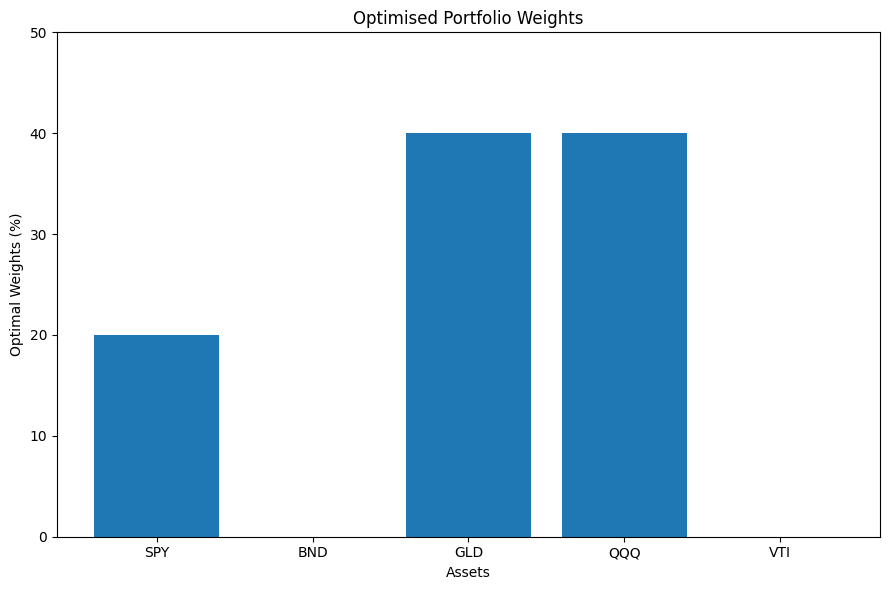

In [257]:
plt.figure(figsize=(9,6))
plt.bar(tickers, optimal_weights *100)

plt.xlabel("Assets")
plt.ylabel("Optimal Weights (%)")
plt.title("Optimised Portfolio Weights")

plt.ylim(
    0,
    max(optimal_weights * 100) + 10
)
plt.tight_layout()
plt.show()

## ***Benchmark Comparison***

> To evaluate whether the optimisation provides an improvement over a simple allocation strategy, the optimised portfolio is compared with an equally weighted portfolio.

## "Does the optimisation improve risk-adjusted performance compared with a simple equal-weight strategy?"

In [258]:
# Already have equal weights stored in variable called initial_weights
equal_weights = initial_weights.copy()

equal_return = expected_return(equal_weights, log_returns)
equal_volatility = standard_deviation(equal_weights, cov_matrix)
equal_sharpe = sharpe_ratio(equal_weights, log_returns, cov_matrix, risk_free_rate)

comparison_table = pd.DataFrame({
    "Portfolio": [
        "Optimised",
        "Equal Weight"
    ],
    "Expected Return": [
        optimal_portfolio_return,
        equal_return
    ],
    "Volatility": [
        optimal_portfolio_volatility,
        equal_volatility
    ],
    "Sharpe Ratio": [
      optimal_sharpe_ratio,
      equal_sharpe
    ]
})

comparison_table = comparison_table.style.format({
    "Expected Return": "{:.2%}",
    "Volatility": "{:.2%}",
    "Sharpe Ratio": "{:.2f}"
}).hide(axis='index')

display(comparison_table)

Portfolio,Expected Return,Volatility,Sharpe Ratio
Optimised,16.26%,15.92%,0.73
Equal Weight,12.53%,13.75%,0.58


### ***Benchmark Comparison Conclusion***

> *Does the optimisation improve risk-adjusted performance compared with a simple equal-weight strategy?*

**Yes, based on the historical data and assumptions used in this analysis.**

The constrained optimised portfolio achieved a higher expected return and a higher Sharpe ratio than the equally weighted benchmark.

- **Expected annual return:** 16.26% vs 12.53%
- **Annualised volatility:** 15.92% vs 13.75%
- **Sharpe ratio:** 0.73 vs 0.58

The optimised portfolio therefore produced stronger historical risk-adjusted performance than the equal-weight benchmark.

## ***Correlation Analysis***

- Portfolio risk depends on the interaction between assets as well as their individual volatility.

- Lower correlations can potentially provide diversification benefits because assets may respond differently to market movements.

In [259]:
correlation_matrix = log_returns.corr()

display(correlation_matrix)

,SPY,BND,GLD,QQQ,VTI
SPY,1.000000,0.174226,0.116438,0.935592,0.996133
BND,0.174226,1.000000,0.296083,0.164862,0.181507
GLD,0.116438,0.296083,1.000000,0.132716,0.120700
QQQ,0.935592,0.164862,0.132716,1.000000,0.930242
VTI,0.996133,0.181507,0.120700,0.930242,1.000000


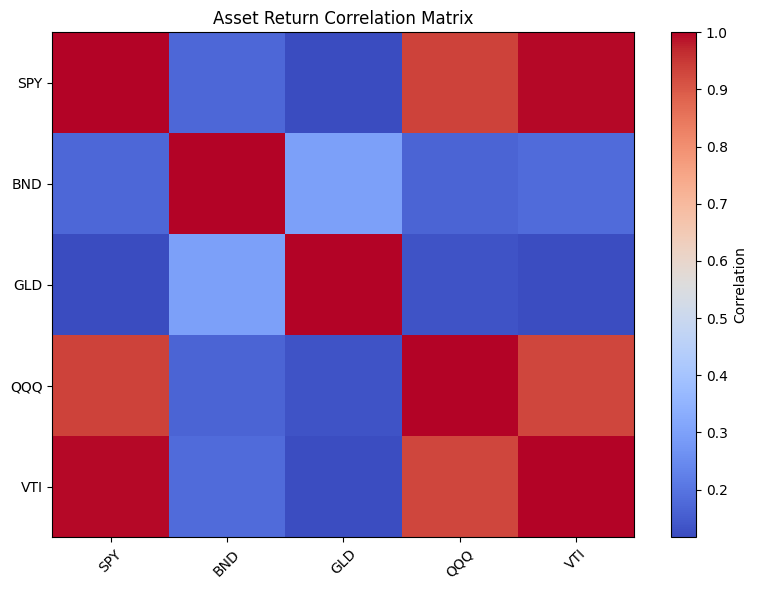

In [260]:
plt.figure(figsize=(8, 6))

plt.imshow(
    correlation_matrix,
    aspect="auto",
    cmap="coolwarm"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(tickers)),
    tickers,
    rotation=45
)

plt.yticks(
    range(len(tickers)),
    tickers
)

plt.title("Asset Return Correlation Matrix")

plt.tight_layout()
plt.show()

## ***Correlation Analysis***

> **BND and GLD have substantially lower correlations with the equity assets**,from the chart.

- Their historically different return behaviour may therefore ***provide greater diversification benefits.***
 #
 #
 #

Therefore, the correlation matrix provides additional context for understanding the allocation produced by the optimisation model above.

# ***Limitations of the model***

This model has several limitations.

***Historical dependence***
- Expected returns and covariance are estimated using historical data and may not represent future market conditions.

***Estimation uncertainty***
- Small changes in expected-return estimates can materially affect the optimal portfolio weights.

***Static allocation***
- The model produces a single portfolio allocation rather than dynamically rebalancing through time.

***Volatility as risk***
- The model uses volatility as the primary measure of portfolio risk. Volatility does not capture all forms of downside or tail risk.

***Risk-free-rate assumption***
- A current risk-free rate is used alongside historical asset returns, which is a simplifying assumption.

***No transaction costs***
- The optimisation does not account for trading costs, taxes or market impact.

These limitations provide opportunities for further development into more advanced quantitative risk-management models.

# ***Recommendation***

Based on the historical data and assumptions used in this analysis,

> the constrained optimised portfolio is preferred to the equally weighted benchmark because it achieved a higher historical expected return and Sharpe ratio.

The optimisation also maintains diversification across equities, bonds and gold, while limiting the maximum allocation to any individual asset to 40%. This constraint helps reduce excessive concentration in a single holding.

- However, the results should not be interpreted as a forecast of future performance.

The optimal allocation is sensitive to the historical period, expected-return estimates, covariance structure and risk-free-rate assumption.

- Therefore, the model is best viewed as a quantitative framework for evaluating portfolio construction rather than a standalone investment decision-making tool.

Before implementing such a strategy, the portfolio should be tested using out-of-sample data and additional risk measures such as Value at Risk, Expected Shortfall and stress testing.